# ECHO Sheet Maker for VS Code

This notebook creates echo sheets from individual experiments prepared as matrices of regaents and runs. 

## Instructions:

1. **Set your file path** in the second cell to point to your experiment Excel file.
2. **Run all cells** to generate the complete ECHO sheet.

Your Excel file must have two tabs:
- `experiment_grid`
- `reagent_concentrations`

### Example `experiment_grid` tab structure:

| Run | CFPS_MM | DNA_Lime | DNA_Apple | DNA_Green | Pyruvate(25mM) | Pyruvate(250mM) | Glucose(25mM) | Glucose(250mM) | HEPES | Water |
|-----|---------|----------|-----------|-----------|----------------|-----------------|---------------|----------------|-------|-------|
| 1   | 675     | 200      |           |           | 0              |                 |               |                |       | 125   |
| 2   | 675     | 200      |           |           | 0              |                 |               |                |       | 125   |
| 3   | 675     | 200      |           |           | 0              |                 |               |                |       | 125   |
| 4   | 675     | 200      |           |           | 25             |                 |               |                |       | 100   |

### Example `reagent_concentrations` tab structure:

| Reagent          | Molarity | Unit   |
|------------------|----------|--------|
| Run              | 30       | mg/mL  |
| CFPS_MM          | 100      | mg/mL  |
| DNA_Lime         | 100      | mg/mL  |
| DNA_Apple        | 100      | mg/mL  |
| DNA_Green        | 100      | mg/mL  |
| Pyruvate(25mM)   | 25       | mM     |
| Pyruvate(250mM)  | 250      | mM     |
| Glucose(25mM)    | 25       | mM     |
| Glucose(250mM)   | 250      | mM     |
| HEPES            | 1000     | mM     |
| Water            |          |        |

**Important Notes:**
- Each run represents a single well in a 384 or 1536-well plate
- Column names must match exactly between tabs
- Molarity and units are optional (e.g., for Water)

In [6]:
import pandas as pd
import numpy as np
import os

# ===== CONFIGURATION =====
# Set your local file path here
file_path = r'C:\Users\d_gar\research\code_and_scripts\Salt_calibration_3_9_26.xlsx'

# Choose your plate type: 384 or 1536
plate_type = 1536

# Sheet names
experiment_grid_sheet_name = 'experiment_grid'
dispensing_sheet_name = 'dispensing_volume'
conditions_sheet_name = 'dispensing_conditions'
plate_reader_data_sheet_name = 'plate_reader_data'

# Validate file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please update the file_path variable with the correct path to your Excel file.")
else:
    print(f"File found: {file_path}")
    print(f"Plate type: {plate_type}")
    
    # Try to read the file
    try:
        df = pd.read_excel(file_path)
        print("Successfully loaded data from Excel file.")
        display(df.head())
    except Exception as e:
        print(f"Error reading file: {e}")

File found: C:\Users\d_gar\research\code_and_scripts\Salt_calibration_3_9_26.xlsx
Plate type: 1536
Successfully loaded data from Excel file.


,Unnamed: 0,1uL,100 uL
0,Panox Emix (mM),0.351,NaN
1,CFPS Extract,0.302,NaN
2,DNA*,0.200,NaN
3,S30 Buffer,NaN,NaN
4,Total:,NaN,NaN


In [7]:
# Read the experiment grid and split volumes based on threshold
df_experiment_grid = pd.read_excel(file_path, sheet_name='experiment_grid')

# Set the threshold for maximum volume per dispense (in nL)
threshold = 44000

# Initialize the new DataFrame with the Run column
new_df = pd.DataFrame(df_experiment_grid['Run'])

# Function to add new columns dynamically
def add_new_column(new_df, col, suffix):
    new_col = f"{col}_{suffix}"
    new_df[new_col] = 0
    return new_col

# Split the columns and move values based on the threshold
for col in df_experiment_grid.columns:
    if col != 'Run':
        suffix = 1
        new_col = add_new_column(new_df, col, suffix)
        total = 0
        for i, value in enumerate(df_experiment_grid[col]):
            if pd.isna(value):  # Check for NaN (blanks) and treat them as zeros
                value = 0
            if total + value > threshold:
                suffix += 1
                new_col = add_new_column(new_df, col, suffix)
                total = 0
            new_df.at[i, new_col] = value
            total += value

# Save to Excel
with pd.ExcelWriter(file_path, mode='a', if_sheet_exists='replace', engine='openpyxl') as writer:
    new_df.to_excel(writer, sheet_name=dispensing_sheet_name, index=False)

print(f"'{dispensing_sheet_name}' sheet has been created.")
display(new_df.head())

'dispensing_volume' sheet has been created.


,Run,Extract1_1,Extract2_1,Extract3_1,Extract4_1,Mg+_1,K+_1,H20_1
0,1,850,0,0,0,0,0,150
1,2,850,0,0,0,0,0,150
2,3,850,0,0,0,0,0,150
3,4,850,0,0,0,0,0,150
4,5,850,0,0,0,0,0,150


In [8]:
# Generate dispensing conditions

# Helper function to generate plate rows
def _generate_plate_rows_local(plate_type_val):
    if plate_type_val == 384:
        return [chr(ord('A') + i) for i in range(16)]  # Rows A-P
    elif plate_type_val == 1536:
        part1 = [chr(ord('A') + i) for i in range(26)]  # Rows A-Z
        part2 = [f"A{chr(ord('A') + i)}" for i in range(6)]  # Rows AA-AF (total 32 rows)
        return part1 + part2
    else:
        raise ValueError(f"Unsupported plate type: {plate_type_val}. Only 384 or 1536 are supported.")

# Function to generate well pattern in row-major order
def generate_well_pattern(start_well, plate_type_val):
    rows = _generate_plate_rows_local(plate_type_val)
    cols_count = 24 if plate_type_val == 384 else 48
    
    well_pattern = [f"{row}{col}" for row in rows for col in range(1, cols_count + 1)]
    
    if start_well not in well_pattern:
        raise ValueError("Invalid starting well position.")
    
    start_index = well_pattern.index(start_well)
    return well_pattern[start_index:] + well_pattern[:start_index]

# Function to get source plate types
def get_source_plate_types(sample_ids, general_default_type, available_types):
    plate_types = [general_default_type] * len(sample_ids)
    
    # Apply conditional override: if 'extract' or 'CFPS' is in Sample ID, use '384PP_Plus_AQ_BP'
    for i, sample_id in enumerate(sample_ids):
        if 'extract' in sample_id.lower() or 'cfps' in sample_id.lower():
            plate_types[i] = '384PP_Plus_AQ_BP'
    
    return plate_types

# Read dispensing volume data
df_dispensing_volume = pd.read_excel(file_path, sheet_name=dispensing_sheet_name)

# Calculate total dispensed volumes
total_dispensed_volumes = df_dispensing_volume.drop(columns=['Run']).sum().to_dict()

# Calculate dead volume
dead_volume = 62000 - threshold
print(f"Calculated dead volume: {dead_volume} nL")

# Create dispensing conditions DataFrame
dispensing_conditions = pd.DataFrame(df_dispensing_volume.columns[1:], columns=['Sample ID'])
dispensing_conditions['Well Volume (nL)'] = dispensing_conditions['Sample ID'].map(total_dispensed_volumes) + dead_volume

# Ask for starting well
start_well = input("Enter the starting well (e.g., B1): ")

# Generate well pattern
well_pattern = generate_well_pattern(start_well, plate_type)
dispensing_conditions['Source Well'] = well_pattern[:len(dispensing_conditions)]

# Set source plate types
available_types = [
    '384PP_Plus_AQ', '384PP_AQ_BP', '384PP_AQ_SP', '384PP_AQ_SP_High',
    '384PP_Plus_AQ_BP', '384PP_Plus_AQ_GP', '384PP_Plus_AQ_GPSA',
    '384PP_Plus_AQ_GPSB', '384PP_Plus_AQ_SP'
]
general_default_type = '384PP_Plus_AQ'
sample_ids = dispensing_conditions['Sample ID'].tolist()
source_plate_types = get_source_plate_types(sample_ids, general_default_type, available_types)
dispensing_conditions['Source Plate Type'] = source_plate_types

# Save to Excel
with pd.ExcelWriter(file_path, mode='a', if_sheet_exists='replace', engine='openpyxl') as writer:
    dispensing_conditions.to_excel(writer, sheet_name=conditions_sheet_name, index=False)

print(f"'{conditions_sheet_name}' sheet has been created.")
display(dispensing_conditions.head())

Calculated dead volume: 18000 nL
'dispensing_conditions' sheet has been created.


,Sample ID,Well Volume (nL),Source Well,Source Plate Type
0,Extract1_1,61350,A1,384PP_Plus_AQ_BP
1,Extract2_1,61350,A2,384PP_Plus_AQ_BP
2,Extract3_1,61350,A3,384PP_Plus_AQ_BP
3,Extract4_1,61350,A4,384PP_Plus_AQ_BP
4,Mg+_1,25200,A5,384PP_Plus_AQ


In [9]:
# Generate ECHO Sheet

# Helper function to generate plate rows
def _generate_plate_rows(plate_type):
    if plate_type == 384:
        return [chr(ord('A') + i) for i in range(16)]  # Rows A-P
    elif plate_type == 1536:
        part1 = [chr(ord('A') + i) for i in range(26)]  # Rows A-Z
        part2 = [f"A{chr(ord('A') + i)}" for i in range(6)]  # Rows AA-AF (total 32 rows)
        return part1 + part2
    else:
        raise ValueError(f"Unsupported plate type: {plate_type}. Only 384 or 1536 are supported.")

# Function to convert well address to index
def well_to_index(start_well, plate_type):
    row_label = start_well[:-1].upper()
    col_num = int(start_well[len(row_label):])
    
    plate_rows = _generate_plate_rows(plate_type)
    num_cols = 24 if plate_type == 384 else 48
    
    try:
        row_index = plate_rows.index(row_label)
        if not (1 <= col_num <= num_cols):
            raise ValueError(f"Column '{col_num}' is out of bounds for a {plate_type}-well plate (1-{num_cols}).")
        index = row_index * num_cols + (col_num - 1)
        return index
    except ValueError as e:
        raise ValueError(f"Invalid well '{start_well}' for plate type {plate_type}: {e}")

# Function to convert run number to well address
def run_to_well(run, plate_type, start_well='A1'):
    plate_rows = _generate_plate_rows(plate_type)
    num_cols = 24 if plate_type == 384 else 48
    
    wells = [f'{r}{c}' for r in plate_rows for c in range(1, num_cols + 1)]
    
    start_index = well_to_index(start_well, plate_type)
    total_wells = len(wells)
    
    destination_index = (run - 1 + start_index) % total_wells
    return wells[destination_index]

# Ask for starting well
start_well = input("Enter the starting well for destination plate (e.g., A1): ")

# Read source data
df_source_data = pd.read_excel(file_path, sheet_name=conditions_sheet_name)

# Melt dispensing volume data
df_melted = df_dispensing_volume.melt(id_vars='Run', var_name='Sample ID', value_name='Transfer Volume')

# Filter out zero/NaN volumes
df_melted = df_melted[df_melted['Transfer Volume'] != 0].copy()
df_melted.dropna(subset=['Transfer Volume'], inplace=True)

# Convert Run to integer
df_melted['Run'] = pd.to_numeric(df_melted['Run'], errors='coerce')
df_melted.dropna(subset=['Run'], inplace=True)
df_melted['Run'] = df_melted['Run'].astype(int)

# Generate destination wells
df_melted['Destination Well'] = df_melted['Run'].apply(lambda x: run_to_well(x, plate_type=plate_type, start_well=start_well))

# Merge with source data
df_melted = pd.merge(df_melted, df_source_data[['Sample ID', 'Source Well', 'Source Plate Type']], on='Sample ID', how='left')

# Add additional columns
df_melted['Source Plate'] = 'Source[1]'
df_melted['Destination Plate Name'] = '1536LDV_Dest' if plate_type == 1536 else '384PP_Dest'
df_melted['Destination Well X Offset'] = 0
df_melted['Destination Well Y Offset'] = 0

# Reorder columns
df_melted = df_melted[['Source Plate', 'Source Plate Type', 'Source Well', 'Sample ID',
                       'Destination Plate Name', 'Destination Well', 'Transfer Volume',
                       'Destination Well X Offset', 'Destination Well Y Offset']]

# Save to Excel
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_melted.to_excel(writer, sheet_name='ECHO_SHEET', index=False)

print("ECHO_SHEET has been created.")
display(df_melted.head())

ECHO_SHEET has been created.


,Source Plate,Source Plate Type,Source Well,Sample ID,Destination Plate Name,Destination Well,Transfer Volume,Destination Well X Offset,Destination Well Y Offset
0,Source[1],384PP_Plus_AQ_BP,A1,Extract1_1,1536LDV_Dest,A1,850,0,0
1,Source[1],384PP_Plus_AQ_BP,A1,Extract1_1,1536LDV_Dest,A2,850,0,0
2,Source[1],384PP_Plus_AQ_BP,A1,Extract1_1,1536LDV_Dest,A3,850,0,0
3,Source[1],384PP_Plus_AQ_BP,A1,Extract1_1,1536LDV_Dest,A4,850,0,0
4,Source[1],384PP_Plus_AQ_BP,A1,Extract1_1,1536LDV_Dest,A5,850,0,0


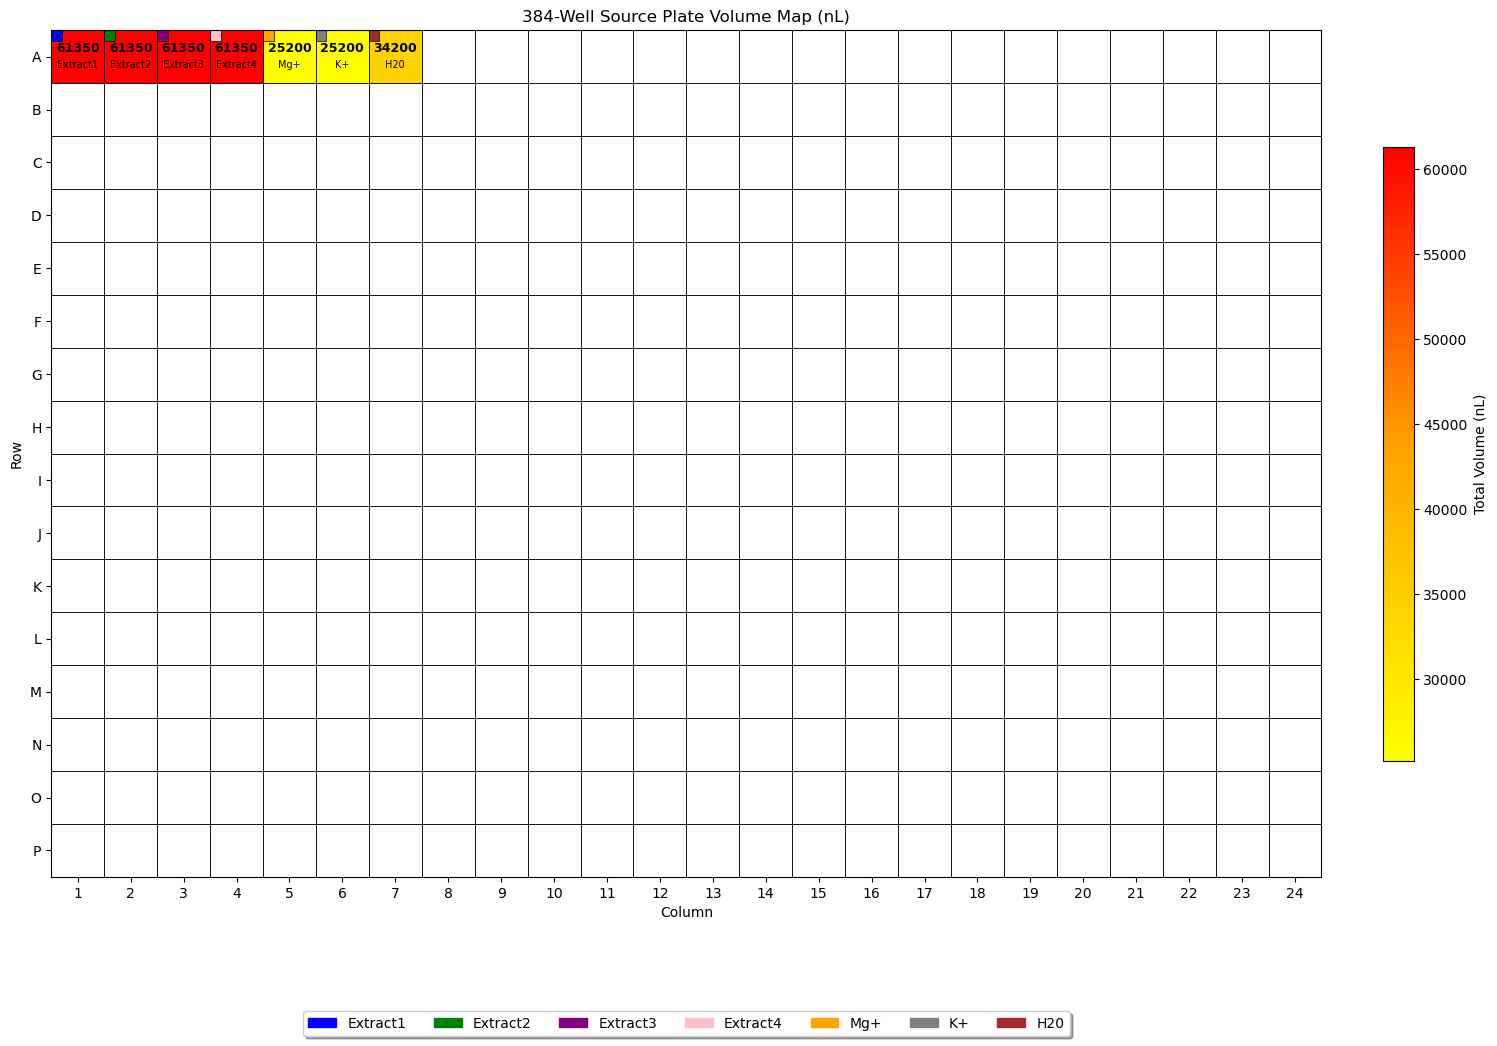

Source plate infographic saved to 'Plate Infographic' sheet.


In [10]:
# Generate Source Plate Infographic
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from openpyxl.drawing.image import Image
from openpyxl import load_workbook
import tempfile

# Source plates are always 384-well
plate_type_infographic = 384

# Helper function for grid coordinates
def well_to_grid_coords(well_id, plate_type):
    rows = _generate_plate_rows(plate_type)
    num_cols_for_type = 24 if plate_type == 384 else 48
    
    row_label = well_id.rstrip('0123456789').upper()
    col_num = int(well_id[len(row_label):])
    
    try:
        row_index = rows.index(row_label)
    except ValueError:
        raise ValueError(f"Invalid row label '{row_label}' for well '{well_id}'.")
    
    col_index = col_num - 1
    
    if not (0 <= col_index < num_cols_for_type):
        raise ValueError(f"Column '{col_num}' is out of bounds for a {plate_type}-well plate (1-{num_cols_for_type}).")
    
    return row_index, col_index

# Read dispensing conditions
df_dispensing_conditions = pd.read_excel(file_path, sheet_name=conditions_sheet_name)
volume_data = df_dispensing_conditions.set_index('Source Well')['Well Volume (nL)']

# Set up plate dimensions
num_rows = 16
num_cols = 24

# Create colormap
cmap = LinearSegmentedColormap.from_list("mycmap", ["yellow", "orange", "red"])
min_vol = volume_data.min() if not volume_data.empty else 0
max_vol = volume_data.max() if not volume_data.empty else 0
norm = Normalize(vmin=min_vol - 1, vmax=max_vol + 1) if min_vol == max_vol else Normalize(vmin=min_vol, vmax=max_vol)

# Generate reagent colors dynamically
unique_base_reagents = df_dispensing_conditions['Sample ID'].apply(
    lambda x: x.split('_')[0] if '_' in x else x
).unique()

color_palette = ['blue', 'green', 'purple', 'pink', 'orange', 'gray', 'brown', 'red',
                'cyan', 'magenta', 'lime', 'teal', 'navy', 'maroon', 'olive', 'indigo']

reagent_text_colors = {reagent: color_palette[i % len(color_palette)] 
                      for i, reagent in enumerate(unique_base_reagents)}

# Create figure
fig, ax = plt.subplots(figsize=(num_cols * 0.7, num_rows * 0.7))

# Draw wells with volumes and reagent indicators
for well_id, total_volume in volume_data.items():
    try:
        row_index, col_index = well_to_grid_coords(well_id, plate_type_infographic)
    except ValueError as e:
        print(f"Skipping well {well_id} due to error: {e}")
        continue
    
    color = cmap(norm(total_volume))
    rect = patches.Rectangle((col_index, row_index), 1, 1, facecolor=color, edgecolor='none')
    ax.add_patch(rect)
    
    # Get reagent for this well
    sample_id_for_well = df_dispensing_conditions.loc[
        df_dispensing_conditions['Source Well'] == well_id, 'Sample ID'
    ].iloc[0]
    base_reagent_name = sample_id_for_well.split('_')[0] if '_' in sample_id_for_well else sample_id_for_well
    reagent_color_for_dot = reagent_text_colors.get(base_reagent_name, 'black')
    
    # Add colored indicator dot
    dot_size = 0.2
    dot_rect = patches.Rectangle((col_index, row_index), dot_size, dot_size,
                                facecolor=reagent_color_for_dot, edgecolor='black', lw=0.5)
    ax.add_patch(dot_rect)
    
    # Add volume text
    ax.text(col_index + 0.5, row_index + 0.35, f'{int(total_volume)}',
           ha='center', va='center', color='black', fontsize=9, weight='bold')
    
    # Add reagent name
    ax.text(col_index + 0.5, row_index + 0.65, base_reagent_name,
           ha='center', va='center', color='black', fontsize=7, wrap=True)

# Draw grid lines
for r_idx in range(num_rows):
    for c_idx in range(num_cols):
        well_outline = patches.Rectangle((c_idx, r_idx), 1, 1, facecolor='none',
                                        edgecolor='black', lw=0.5)
        ax.add_patch(well_outline)

# Set axis properties
ax.set_xlim(0, num_cols)
ax.set_ylim(0, num_rows)
ax.set_xticks(np.arange(0.5, num_cols, 1), labels=np.arange(1, num_cols + 1))
ax.set_yticks(np.arange(0.5, num_rows, 1), labels=_generate_plate_rows(plate_type_infographic))
ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.set_title(f'{plate_type_infographic}-Well Source Plate Volume Map (nL)')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Total Volume (nL)')

# Add legend
reagent_handles = [patches.Patch(color=color_val, label=reagent_name)
                  for reagent_name, color_val in reagent_text_colors.items()]
ax.legend(handles=reagent_handles, bbox_to_anchor=(0.5, -0.15), loc='upper center',
         ncol=len(reagent_handles), fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# Save to Excel
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
    image_path = tmp.name
    fig.savefig(image_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

wb = load_workbook(file_path)
image_sheet_name = 'Plate Infographic'
if image_sheet_name in wb.sheetnames:
    del wb[image_sheet_name]
ws = wb.create_sheet(image_sheet_name)
img = Image(image_path)
ws.add_image(img, 'A1')
wb.save(file_path)
os.remove(image_path)

print(f"Source plate infographic saved to '{image_sheet_name}' sheet.")

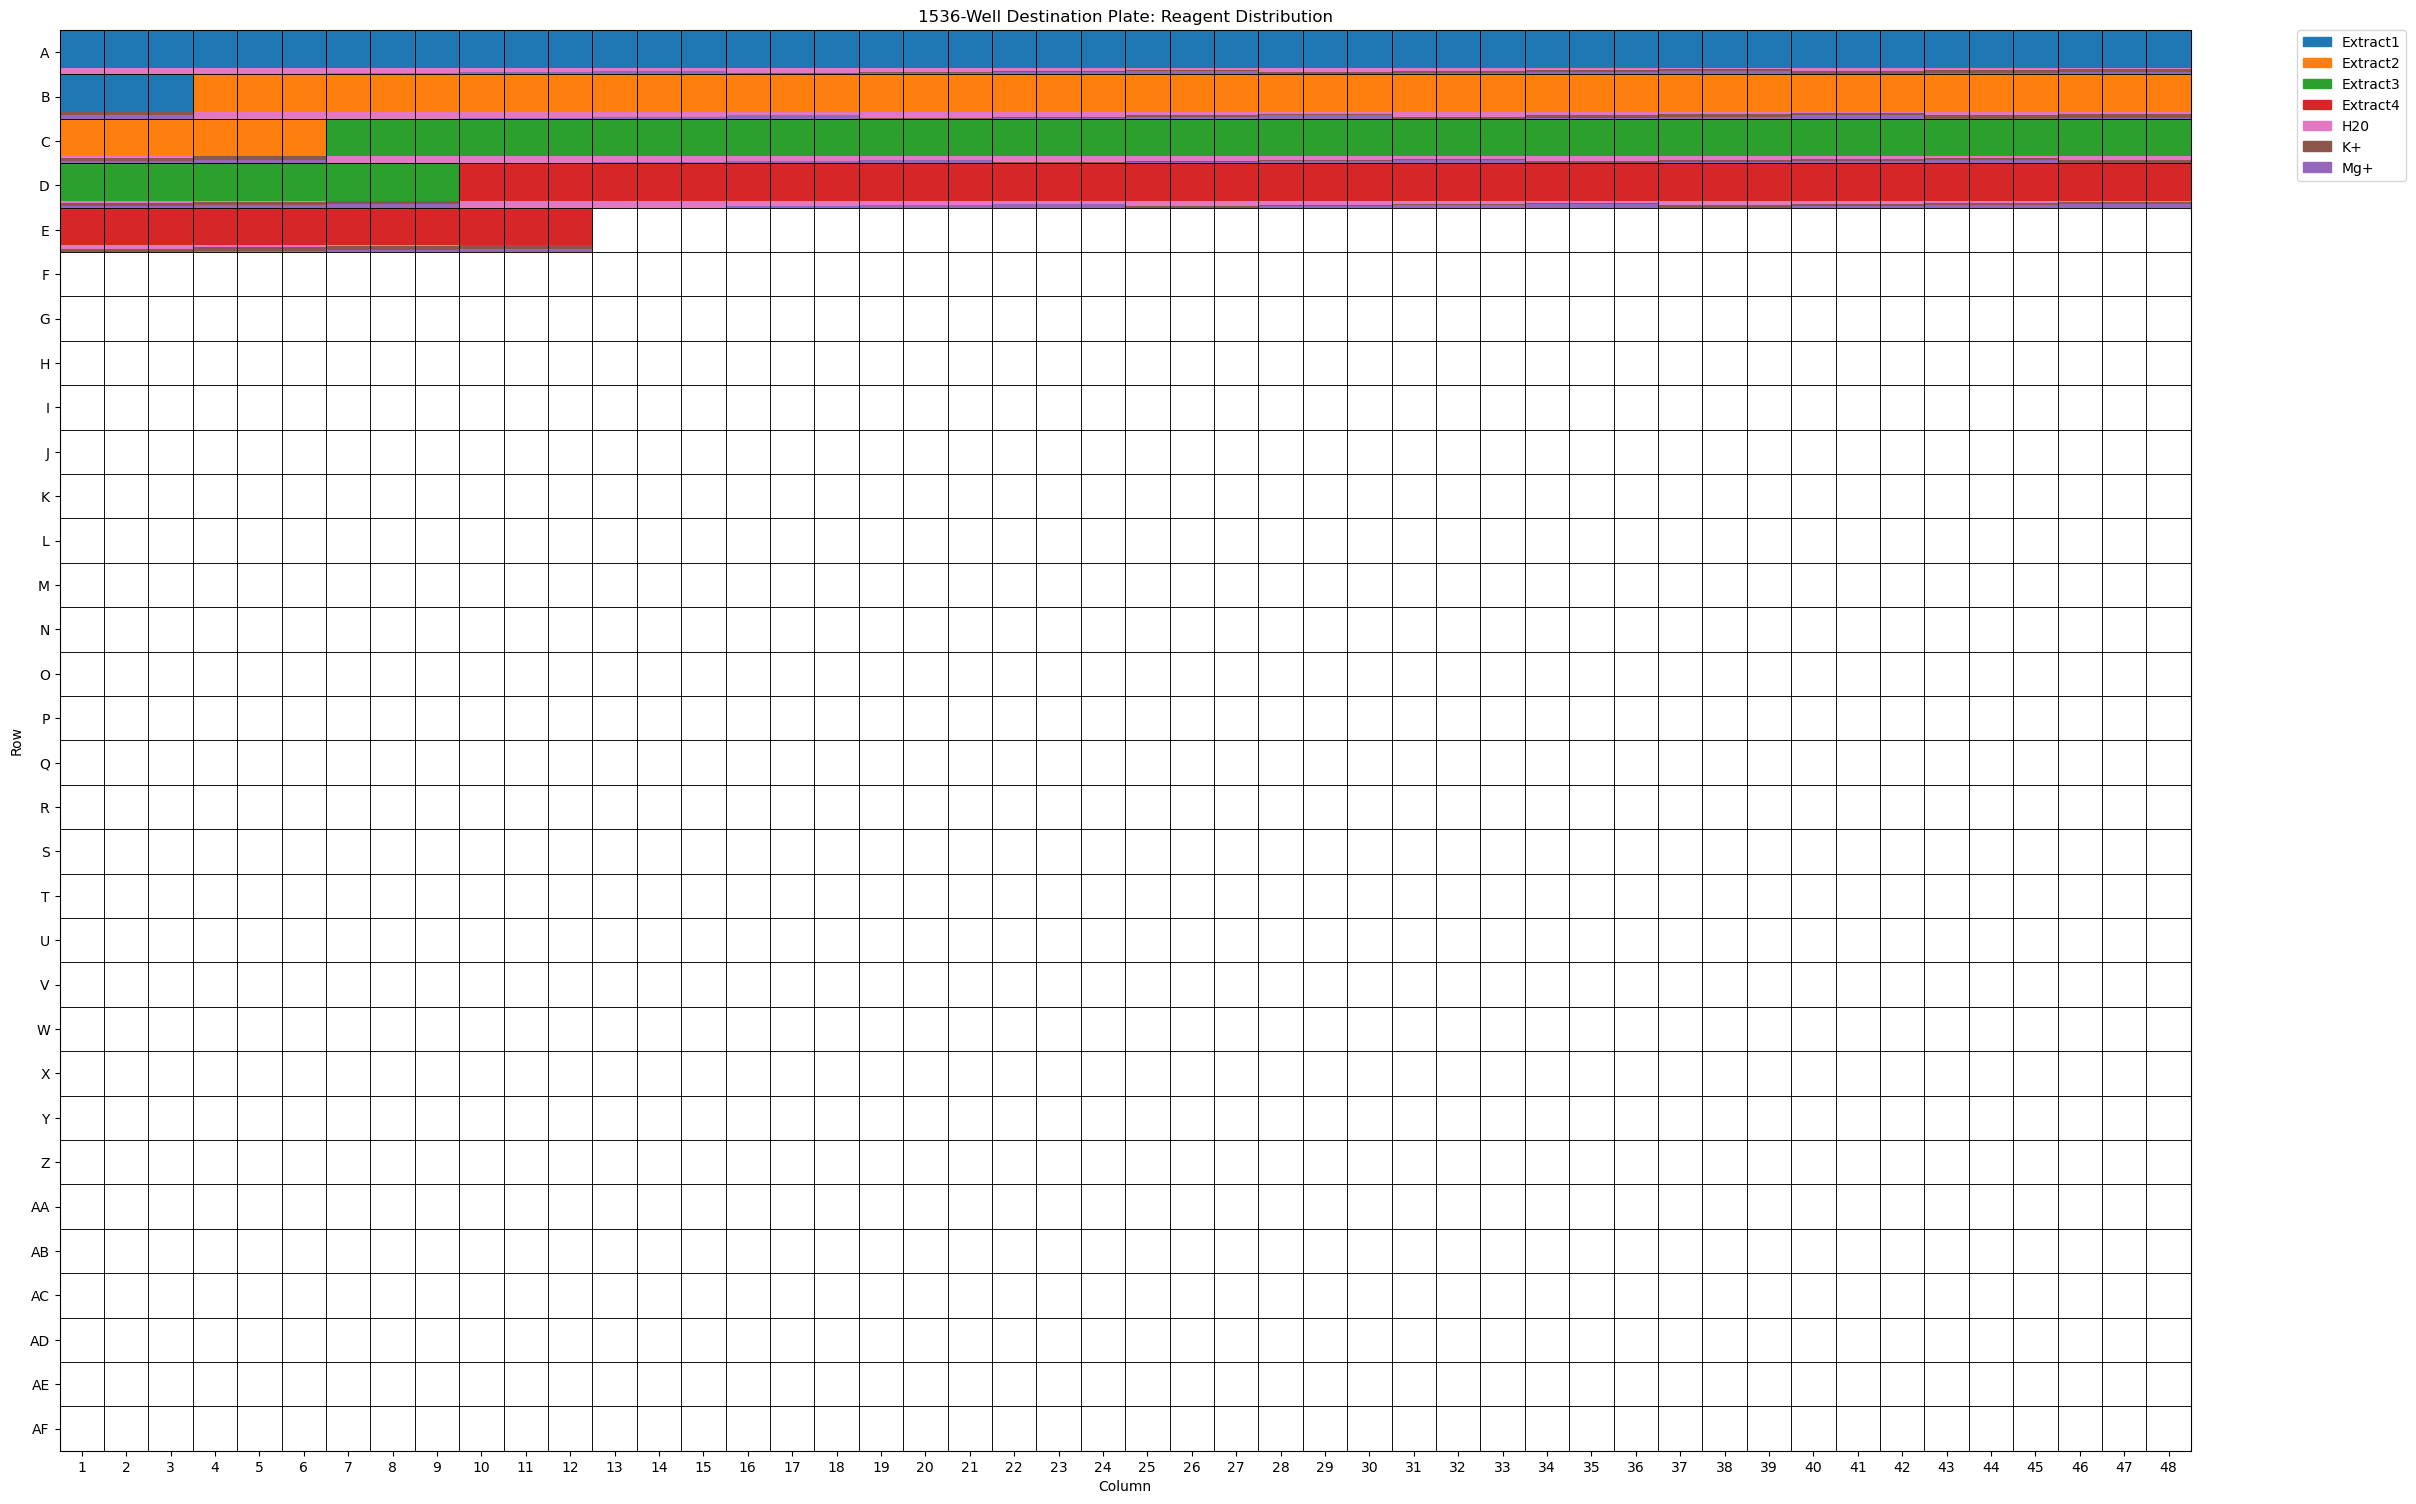

Destination plate reagent distribution infographic complete.


In [11]:
# Generate Destination Plate Reagent Distribution Infographic

# Helper function to extract base reagent name
def get_base_reagent_name(sample_id):
    return sample_id.split('_')[0] if '_' in sample_id else sample_id

# Extract base reagent names
df_melted['Base Reagent'] = df_melted['Sample ID'].apply(get_base_reagent_name)

# Calculate total transfer volume for each base reagent in each destination well
df_reagent_volumes = df_melted.groupby(['Destination Well', 'Base Reagent'])['Transfer Volume'].sum().reset_index()

# Pivot to get reagents as columns
df_proportions = df_reagent_volumes.pivot_table(
    index='Destination Well',
    columns='Base Reagent',
    values='Transfer Volume',
    fill_value=0
)

# Calculate proportions
df_total_volume_per_well = df_proportions.sum(axis=1)
df_proportions = df_proportions.div(df_total_volume_per_well, axis=0)

# Generate reagent colors
unique_base_reagents = df_melted['Base Reagent'].unique()
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
                '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78',
                '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7',
                '#dbdb8d', '#9edae5']

reagent_colors = {reagent: color_palette[i % len(color_palette)]
                 for i, reagent in enumerate(unique_base_reagents)}

# Set plate dimensions
num_rows = 32 if plate_type == 1536 else 16
num_cols = 48 if plate_type == 1536 else 24

reagent_names = [col for col in df_proportions.columns if not col.startswith('Unnamed:')]

# Create figure
fig, ax = plt.subplots(figsize=(num_cols * 0.5, num_rows * 0.5))

# Draw stacked reagent distribution
for well_id, proportions_series in df_proportions.iterrows():
    try:
        row_index, col_index = well_to_grid_coords(well_id, plate_type)
    except ValueError as e:
        print(f"Skipping well {well_id} due to error: {e}")
        continue
    
    current_reagent_proportions = proportions_series[reagent_names]
    total_relevant_proportion = current_reagent_proportions.sum()
    
    if total_relevant_proportion == 0:
        continue
    
    normalized_proportions = current_reagent_proportions / total_relevant_proportion
    current_stack_height = 0
    
    for reagent in reagent_names:
        proportion = normalized_proportions.get(reagent, 0)
        
        if proportion > 0:
            reagent_color = reagent_colors.get(reagent)
            if reagent_color is None:
                continue
            
            bottom = current_stack_height
            height = proportion
            
            rect = patches.Rectangle(
                (col_index, row_index + bottom),
                1,
                height,
                facecolor=reagent_color,
                edgecolor='none'
            )
            ax.add_patch(rect)
            current_stack_height += proportion

# Draw grid lines
for r_idx in range(num_rows):
    for c_idx in range(num_cols):
        well_outline = patches.Rectangle((c_idx, r_idx), 1, 1, facecolor='none',
                                        edgecolor='black', lw=0.5)
        ax.add_patch(well_outline)

# Set axis properties
ax.set_xlim(0, num_cols)
ax.set_ylim(0, num_rows)
ax.set_xticks(np.arange(0.5, num_cols, 1), labels=np.arange(1, num_cols + 1))
ax.set_yticks(np.arange(0.5, num_rows, 1), labels=_generate_plate_rows(plate_type))
ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.set_title(f'{plate_type}-Well Destination Plate: Reagent Distribution')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()

# Add legend
handles = [patches.Patch(color=reagent_colors[reagent], label=reagent) for reagent in reagent_names]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

print("Destination plate reagent distribution infographic complete.")

## Generate Headers Sheet

This section calculates the final concentrations of each reagent in each destination well and creates a "Headings" sheet. This sheet is useful for quickly labeling plots and understanding the composition of each well.

The calculations:
1. Extract base reagent names from Sample IDs (removing numeric suffixes)
2. Calculate total volume for each destination well
3. Use the reagent_concentrations sheet to determine stock concentrations
4. Calculate final concentrations: (transfer_volume × stock_concentration) / total_well_volume
5. Create a pivot table with reagents as rows and wells as columns (sorted numerically)

**Example Output:**

| Base Reagent     | A1   | A2   | A3   |
|------------------|------|------|------|
| CFPS_MM          | 20.25| 20.25| 20.25|
| DNA_Lime         | 6.0  | 6.0  | 0    |
| Pyruvate(25mM)   | 0    | 2.5  | 5.0  |
| Water            | 0    | 0    | 0    |

In [12]:
import re

# Load reagent concentrations data
try:
    df_reagent_concentrations = pd.read_excel(file_path, sheet_name='reagent_concentrations')
    reagent_data = df_reagent_concentrations.set_index('Reagent')[['Molarity', 'Unit']].to_dict('index')
    print("Loaded reagent concentrations data.")
except Exception as e:
    print(f"Error loading reagent_concentrations sheet: {e}")
    print("Skipping headers generation.")
    reagent_data = {}

if reagent_data:
    # Extract base reagent names (remove numeric suffixes like '_1', '_2')
    def get_base_reagent_name(sample_id):
        parts = sample_id.split('_')
        if len(parts) > 1 and parts[-1].isdigit():
            return '_'.join(parts[:-1])
        return sample_id
    
    df_melted['Base Reagent'] = df_melted['Sample ID'].apply(get_base_reagent_name)
    
    # Calculate total volume per destination well
    df_total_volume_per_well = df_melted.groupby('Destination Well')['Transfer Volume'].sum().reset_index()
    df_total_volume_per_well.rename(columns={'Transfer Volume': 'Total_Well_Volume'}, inplace=True)
    
    # Merge with total volumes
    df_merged = pd.merge(df_melted, df_total_volume_per_well, on='Destination Well', how='left')
    
    # Calculate final concentrations
    def calculate_final_concentration(row):
        base_reagent = row['Base Reagent']
        reagent_transfer_volume = row['Transfer Volume']
        total_well_volume = row['Total_Well_Volume']
        
        if base_reagent in reagent_data and 'Molarity' in reagent_data[base_reagent]:
            stock_molarity = reagent_data[base_reagent]['Molarity']
            if pd.notna(stock_molarity) and total_well_volume > 0:
                final_concentration = (reagent_transfer_volume * stock_molarity) / total_well_volume
                return round(final_concentration, 2)
        return 0.0
    
    df_merged['Final Concentration'] = df_merged.apply(calculate_final_concentration, axis=1)
    
    # Aggregate concentrations (max per reagent per well) and pivot
    df_aggregated = df_merged.groupby(['Base Reagent', 'Destination Well'])['Final Concentration'].max().reset_index()
    df_concentrations_pivot = df_aggregated.pivot_table(
        index='Base Reagent', 
        columns='Destination Well', 
        values='Final Concentration', 
        fill_value=0
    )
    
    # Sort columns numerically (e.g., A1, A2, ... A10, not A1, A10, A2)
    def sort_key_wells(col_name):
        match = re.match(r'([A-Za-z]+)(\d+)', col_name)
        if match:
            letter_part = match.group(1)
            number_part = int(match.group(2))
            return (letter_part, number_part)
        return (col_name, 0)
    
    sorted_columns = sorted(df_concentrations_pivot.columns, key=sort_key_wells)
    df_concentrations_pivot = df_concentrations_pivot[sorted_columns]
    
    # Save to Headings sheet
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df_concentrations_pivot.to_excel(writer, sheet_name='Headings', index=True)
    
    print("Headers sheet created successfully!")
    print(f"\nPreview of final concentrations (first 5 wells):")
    display(df_concentrations_pivot.iloc[:, :5])
else:
    print("Headers sheet not created - reagent_concentrations data not available.")

Loaded reagent concentrations data.
Headers sheet created successfully!

Preview of final concentrations (first 5 wells):


Destination Well,A1,A2,A3,A4,A5
Base Reagent,,,,,
Extract1,25.5,25.5,25.5,25.5,25.5
Extract2,0.0,0.0,0.0,0.0,0.0
Extract3,0.0,0.0,0.0,0.0,0.0
Extract4,0.0,0.0,0.0,0.0,0.0
H20,0.0,0.0,0.0,0.0,0.0
K+,0.0,0.0,0.0,0.0,0.0
Mg+,0.0,0.0,0.0,0.0,0.0


In [13]:
# Create consolidated well headers
if reagent_data and 'df_concentrations_pivot' in locals():
    well_headers = {}
    
    # Iterate through each well (column in the pivot table)
    for well in df_concentrations_pivot.columns:
        header_parts = []
        
        # Iterate through each reagent (row in the pivot table)
        for reagent in df_concentrations_pivot.index:
            concentration = df_concentrations_pivot.loc[reagent, well]
            
            # Only include reagents with non-zero concentrations
            if concentration > 0:
                # Get unit from reagent_data
                unit = reagent_data.get(reagent, {}).get('Unit', '')
                if pd.notna(unit) and unit:
                    header_parts.append(f"{reagent}: {concentration} {unit}")
                else:
                    header_parts.append(f"{reagent}: {concentration}")
        
        # Join all parts with ", " and store in dictionary
        well_headers[well] = ", ".join(header_parts) if header_parts else "Empty"
    
    # Create DataFrame with well names and their consolidated headers
    df_well_headers = pd.DataFrame(list(well_headers.items()), columns=['Well', 'Header'])
    
    # Save to "well headers" sheet
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df_well_headers.to_excel(writer, sheet_name='well headers', index=False)
    
    print("Well headers sheet created successfully!")
    print(f"\nPreview of consolidated headers (first 10 wells):")
    display(df_well_headers.head(10))
else:
    print("Well headers sheet not created - required data not available.")

Well headers sheet created successfully!

Preview of consolidated headers (first 10 wells):


,Well,Header
0,A1,Extract1: 25.5 mM
1,A2,Extract1: 25.5 mM
2,A3,Extract1: 25.5 mM
3,A4,Extract1: 25.5 mM
4,A5,Extract1: 25.5 mM
5,A6,Extract1: 25.5 mM
6,A7,"Extract1: 25.5 mM, Mg+: 5.0 mM"
7,A8,"Extract1: 25.5 mM, Mg+: 5.0 mM"
8,A9,"Extract1: 25.5 mM, Mg+: 5.0 mM"
9,A10,"Extract1: 25.5 mM, Mg+: 10.0 mM"
